# 07. Model Evaluation and Tuning

## Objective

Evaluate and tune the baseline models for 30-day hospital readmission prediction.

### Evaluation Principles

- Preserve the approved patient-level train/test split.
- Use training data only for model selection and tuning.
- Keep the test set untouched until final evaluation.
- Focus on minority-class performance rather than accuracy alone.
- Evaluate Precision, Recall, F1-score, ROC-AUC, PR-AUC, and confusion matrix.
- Perform threshold analysis because the default 0.50 threshold may not be appropriate for this imbalanced classification problem.

### Models

1. Logistic Regression
2. Random Forest

### Planned Evaluation

1. Load the approved patient-level train/test split.
2. Reuse the established preprocessing methodology.
3. Perform cross-validation on the training data.
4. Tune model parameters using training data only.
5. Analyze prediction thresholds.
6. Select candidate model configurations based on predefined evaluation criteria.
7. Evaluate the selected configuration once on the untouched test set.

In [1]:
# ============================================================
# 1. Imports and Configuration
# ============================================================

import os
import random

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import StratifiedKFold, cross_validate

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc
)

import matplotlib.pyplot as plt


# Reproducibility
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)


# Target and patient identifier
TARGET = "readmitted_30"
PATIENT_ID = "patient_nbr"

print("Imports successful.")
print("Target:", TARGET)
print("Random state:", RANDOM_STATE)

Imports successful.
Target: readmitted_30
Random state: 42


In [3]:
# ============================================================
# 2. Load Dataset and Recreate Target
# ============================================================

DATA_PATH = "../data/raw/diabetic_data.csv"

df = pd.read_csv(DATA_PATH)

# Recreate the 30-day readmission target
# 1 = readmitted within 30 days
# 0 = not readmitted within 30 days
df[TARGET] = (df["readmitted"] == "<30").astype(int)

print("Dataset shape:", df.shape)
print("\nColumns:", len(df.columns))

print("\nTarget column present:", TARGET in df.columns)
print("Patient ID column present:", PATIENT_ID in df.columns)

print("\nTarget distribution:")
print(df[TARGET].value_counts())

print("\nTarget proportions:")
print(df[TARGET].value_counts(normalize=True))

Dataset shape: (101766, 51)

Columns: 51

Target column present: True
Patient ID column present: True

Target distribution:
readmitted_30
0    90409
1    11357
Name: count, dtype: int64

Target proportions:
readmitted_30
0    0.888401
1    0.111599
Name: proportion, dtype: float64


In [4]:
# ============================================================
# 3. Load Approved Patient-Level Split
# ============================================================

TRAIN_PATIENTS_PATH = "../data/processed/split/train_patients.csv"
TEST_PATIENTS_PATH = "../data/processed/split/test_patients.csv"

train_patients = pd.read_csv(TRAIN_PATIENTS_PATH)[PATIENT_ID]
test_patients = pd.read_csv(TEST_PATIENTS_PATH)[PATIENT_ID]

print("Training patients:", train_patients.nunique())
print("Test patients:", test_patients.nunique())

# Verify patient-level separation
patient_overlap = set(train_patients).intersection(set(test_patients))

print("Patients in both split files:", len(patient_overlap))

if len(patient_overlap) == 0:
    print("PASS: Approved patient-level split has no overlap.")
else:
    print("WARNING: Patient overlap detected!")

# Recreate the encounter-level train/test data
train_df = df[df[PATIENT_ID].isin(train_patients)].copy()
test_df = df[df[PATIENT_ID].isin(test_patients)].copy()

print("\nTraining encounters:", len(train_df))
print("Test encounters:", len(test_df))

print("\nTraining target distribution:")
print(train_df[TARGET].value_counts())

print("\nTest target distribution:")
print(test_df[TARGET].value_counts())

Training patients: 57214
Test patients: 14304
Patients in both split files: 0
PASS: Approved patient-level split has no overlap.

Training encounters: 81477
Test encounters: 20289

Training target distribution:
readmitted_30
0    72289
1     9188
Name: count, dtype: int64

Test target distribution:
readmitted_30
0    18120
1     2169
Name: count, dtype: int64


In [5]:
# ============================================================
# 4. Separate Features and Target
# ============================================================

ID_COLUMNS = ["encounter_id", PATIENT_ID]

# Separate target
y_train = train_df[TARGET].copy()
y_test = test_df[TARGET].copy()

# Remove target and identifiers
X_train = train_df.drop(columns=[TARGET] + ID_COLUMNS)
X_test = test_df.drop(columns=[TARGET] + ID_COLUMNS)

# Remove original readmission outcome
if "readmitted" in X_train.columns:
    X_train = X_train.drop(columns=["readmitted"])
    X_test = X_test.drop(columns=["readmitted"])

# Convert literal '?' values to actual missing values
X_train = X_train.replace("?", np.nan)
X_test = X_test.replace("?", np.nan)

# Verify no '?' values remain
print(
    "Remaining '?' values in X_train:",
    (X_train == "?").sum().sum()
)

print(
    "Remaining '?' values in X_test:",
    (X_test == "?").sum().sum()
)

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTarget:", TARGET)
print("Identifier columns removed:", ID_COLUMNS)

print(
    "Original readmitted column present in X_train:",
    "readmitted" in X_train.columns
)

Remaining '?' values in X_train: 0
Remaining '?' values in X_test: 0

X_train shape: (81477, 47)
X_test shape: (20289, 47)
y_train shape: (81477,)
y_test shape: (20289,)

Target: readmitted_30
Identifier columns removed: ['encounter_id', 'patient_nbr']
Original readmitted column present in X_train: False


In [6]:
# ============================================================
# 5. Apply Finalized Feature Removal Decisions
# ============================================================

FEATURES_TO_REMOVE = [
    "examide",
    "citoglipton",
    "weight",
    "payer_code"
]

X_train = X_train.drop(
    columns=FEATURES_TO_REMOVE,
    errors="ignore"
)

X_test = X_test.drop(
    columns=FEATURES_TO_REMOVE,
    errors="ignore"
)

print("Removed features:", FEATURES_TO_REMOVE)

print("\nX_train shape after feature removal:", X_train.shape)
print("X_test shape after feature removal:", X_test.shape)

remaining_removed_features = [
    feature
    for feature in FEATURES_TO_REMOVE
    if feature in X_train.columns or feature in X_test.columns
]

print(
    "\nRemaining removed features:",
    remaining_removed_features
)

Removed features: ['examide', 'citoglipton', 'weight', 'payer_code']

X_train shape after feature removal: (81477, 43)
X_test shape after feature removal: (20289, 43)

Remaining removed features: []


In [7]:
# ============================================================
# 6. Define Feature Types
# ============================================================

NUMERICAL_FEATURES = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

CATEGORICAL_FEATURES = [
    column
    for column in X_train.columns
    if column not in NUMERICAL_FEATURES
]

HIGH_CARDINALITY_FEATURES = [
    "diag_1",
    "diag_2",
    "diag_3",
    "medical_specialty"
]

print("Numerical features:", len(NUMERICAL_FEATURES))
print("Categorical features:", len(CATEGORICAL_FEATURES))
print("Total predictors:", len(NUMERICAL_FEATURES) + len(CATEGORICAL_FEATURES))

print("\nNumerical features:")
print(NUMERICAL_FEATURES)

print("\nHigh-cardinality categorical features:")
print(HIGH_CARDINALITY_FEATURES)

# Verification
missing_numerical = [
    feature for feature in NUMERICAL_FEATURES
    if feature not in X_train.columns
]

missing_high_cardinality = [
    feature for feature in HIGH_CARDINALITY_FEATURES
    if feature not in X_train.columns
]

print("\nMissing numerical features:", missing_numerical)
print("Missing high-cardinality features:", missing_high_cardinality)

Numerical features: 8
Categorical features: 35
Total predictors: 43

Numerical features:
['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

High-cardinality categorical features:
['diag_1', 'diag_2', 'diag_3', 'medical_specialty']

Missing numerical features: []
Missing high-cardinality features: []


In [8]:
# ============================================================
# 7. Build Leakage-Safe Preprocessing Pipeline
# ============================================================

numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(
            strategy="constant",
            fill_value="Unknown"
        )),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, NUMERICAL_FEATURES),
        ("cat", categorical_pipeline, CATEGORICAL_FEATURES)
    ]
)

print("Preprocessing pipeline created successfully.")
print("Numerical pipeline: median imputation + StandardScaler")
print("Categorical pipeline: Unknown imputation + OneHotEncoder")

Preprocessing pipeline created successfully.
Numerical pipeline: median imputation + StandardScaler
Categorical pipeline: Unknown imputation + OneHotEncoder


In [9]:
# ============================================================
# 8. Fit Preprocessing on Training Data Only
# ============================================================

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training data transformed.")
print("Test data transformed using the training-fitted pipeline.")

print("\nProcessed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

# Verify feature counts match
print(
    "\nFeature count matches:",
    X_train_processed.shape[1] == X_test_processed.shape[1]
)

Training data transformed.
Test data transformed using the training-fitted pipeline.

Processed training shape: (81477, 2391)
Processed test shape: (20289, 2391)

Feature count matches: True


In [10]:
# ============================================================
# 8A. Diagnose Encoded Feature Count
# ============================================================

categorical_encoder = (
    preprocessor
    .named_transformers_["cat"]
    .named_steps["onehot"]
)

encoded_feature_counts = {
    feature: len(categories)
    for feature, categories in zip(
        CATEGORICAL_FEATURES,
        categorical_encoder.categories_
    )
}

encoded_features_total = sum(encoded_feature_counts.values())

print("Encoded categorical features:", encoded_features_total)
print("Numerical features:", len(NUMERICAL_FEATURES))
print("Total transformed features:", encoded_features_total + len(NUMERICAL_FEATURES))

print("\nCategorical feature category counts:")

for feature, count in encoded_feature_counts.items():
    print(f"{feature}: {count}")

Encoded categorical features: 2383
Numerical features: 8
Total transformed features: 2391

Categorical feature category counts:
race: 6
gender: 3
age: 10
admission_type_id: 8
discharge_disposition_id: 26
admission_source_id: 17
medical_specialty: 70
diag_1: 697
diag_2: 715
diag_3: 752
max_glu_serum: 4
A1Cresult: 4
metformin: 4
repaglinide: 4
nateglinide: 4
chlorpropamide: 3
glimepiride: 4
acetohexamide: 2
glipizide: 4
glyburide: 4
tolbutamide: 2
pioglitazone: 4
rosiglitazone: 4
acarbose: 4
miglitol: 4
troglitazone: 2
tolazamide: 3
insulin: 4
glyburide-metformin: 4
glipizide-metformin: 2
glimepiride-pioglitazone: 2
metformin-rosiglitazone: 2
metformin-pioglitazone: 1
change: 2
diabetesMed: 2


In [11]:
# ============================================================
# 9. Verify Processed Data
# ============================================================

print("Training shape:", X_train_processed.shape)
print("Test shape:", X_test_processed.shape)

print("\nTraining target shape:", y_train.shape)
print("Test target shape:", y_test.shape)

print(
    "\nFeature count matches:",
    X_train_processed.shape[1] == X_test_processed.shape[1]
)

# Verify no missing values remain after preprocessing
print(
    "Training missing values:",
    np.isnan(X_train_processed.toarray()).sum()
)

print(
    "Test missing values:",
    np.isnan(X_test_processed.toarray()).sum()
)

Training shape: (81477, 2391)
Test shape: (20289, 2391)

Training target shape: (81477,)
Test target shape: (20289,)

Feature count matches: True
Training missing values: 0
Test missing values: 0


In [12]:
from pathlib import Path

model_dir = Path("../models")

print("Model directory exists:", model_dir.exists())

if model_dir.exists():
    print("\nModel files:")
    for file in model_dir.iterdir():
        print("-", file.name)

Model directory exists: False


In [13]:
from pathlib import Path
import joblib

MODEL_DIR = Path("../models")

logistic_model = joblib.load(
    MODEL_DIR / "logistic_regression_baseline.joblib"
)

random_forest_model = joblib.load(
    MODEL_DIR / "random_forest_baseline.joblib"
)

preprocessor = joblib.load(
    MODEL_DIR / "preprocessor.joblib"
)

print("Models and preprocessor loaded successfully.")
print("Logistic Regression:", type(logistic_model).__name__)
print("Random Forest:", type(random_forest_model).__name__)
print("Preprocessor:", type(preprocessor).__name__)

Models and preprocessor loaded successfully.
Logistic Regression: LogisticRegression
Random Forest: RandomForestClassifier
Preprocessor: ColumnTransformer


In [14]:
# Transform evaluation data using the training-fitted preprocessor

X_test_processed = preprocessor.transform(X_test)

print("Evaluation data transformed successfully.")
print("Processed test shape:", X_test_processed.shape)
print("Expected test rows:", len(y_test))
print(
    "Feature count:",
    X_test_processed.shape[1]
)

Evaluation data transformed successfully.
Processed test shape: (20289, 2391)
Expected test rows: 20289
Feature count: 2391


In [15]:
# Generate predictions using the saved baseline models

# Logistic Regression
lr_test_pred = logistic_model.predict(X_test_processed)
lr_test_proba = logistic_model.predict_proba(X_test_processed)[:, 1]

# Random Forest
rf_test_pred = random_forest_model.predict(X_test_processed)
rf_test_proba = random_forest_model.predict_proba(X_test_processed)[:, 1]

print("Predictions generated successfully.")

print("\nLogistic Regression:")
print("Predictions:", len(lr_test_pred))
print("Probabilities:", len(lr_test_proba))

print("\nRandom Forest:")
print("Predictions:", len(rf_test_pred))
print("Probabilities:", len(rf_test_proba))

Predictions generated successfully.

Logistic Regression:
Predictions: 20289
Probabilities: 20289

Random Forest:
Predictions: 20289
Probabilities: 20289


In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Logistic Regression metrics
lr_metrics = {
    "Accuracy": accuracy_score(y_test, lr_test_pred),
    "Precision": precision_score(y_test, lr_test_pred, zero_division=0),
    "Recall": recall_score(y_test, lr_test_pred, zero_division=0),
    "F1": f1_score(y_test, lr_test_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, lr_test_proba),
    "PR-AUC": average_precision_score(y_test, lr_test_proba)
}

# Random Forest metrics
rf_metrics = {
    "Accuracy": accuracy_score(y_test, rf_test_pred),
    "Precision": precision_score(y_test, rf_test_pred, zero_division=0),
    "Recall": recall_score(y_test, rf_test_pred, zero_division=0),
    "F1": f1_score(y_test, rf_test_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, rf_test_proba),
    "PR-AUC": average_precision_score(y_test, rf_test_proba)
}

print("=== Logistic Regression ===")
for metric, value in lr_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\n=== Random Forest ===")
for metric, value in rf_metrics.items():
    print(f"{metric}: {value:.4f}")

=== Logistic Regression ===
Accuracy: 0.6612
Precision: 0.1711
Recall: 0.5643
F1: 0.2626
ROC-AUC: 0.6635
PR-AUC: 0.2122

=== Random Forest ===
Accuracy: 0.8926
Precision: 0.4583
Recall: 0.0254
F1: 0.0481
ROC-AUC: 0.6808
PR-AUC: 0.2173


=== Logistic Regression Confusion Matrix ===
[[12192  5928]
 [  945  1224]]


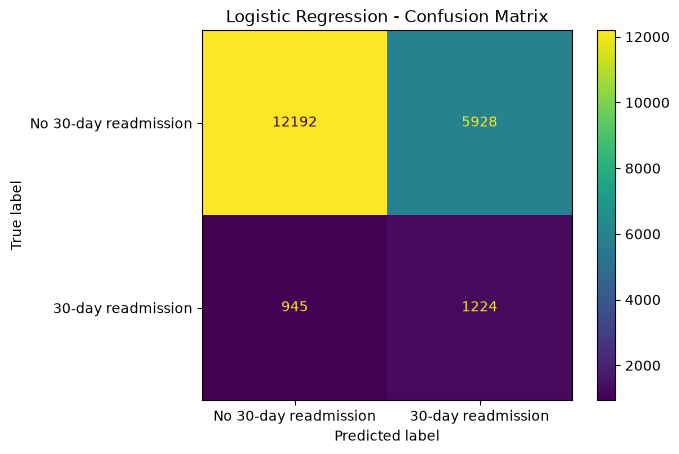


=== Random Forest Confusion Matrix ===
[[18055    65]
 [ 2114    55]]


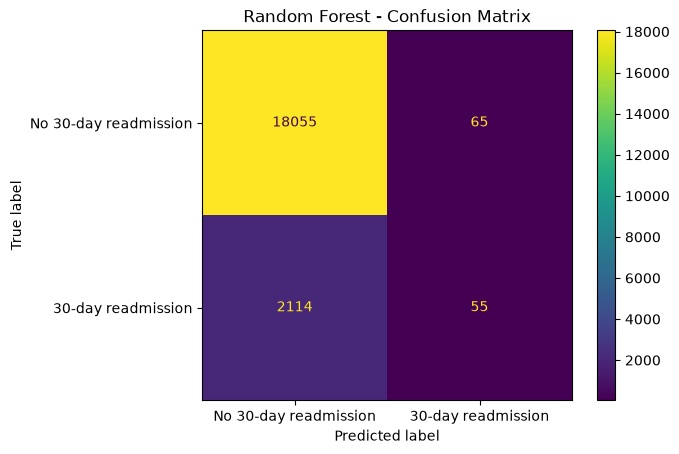

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Logistic Regression confusion matrix
lr_cm = confusion_matrix(y_test, lr_test_pred)

print("=== Logistic Regression Confusion Matrix ===")
print(lr_cm)

ConfusionMatrixDisplay(
    confusion_matrix=lr_cm,
    display_labels=["No 30-day readmission", "30-day readmission"]
).plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()


# Random Forest confusion matrix
rf_cm = confusion_matrix(y_test, rf_test_pred)

print("\n=== Random Forest Confusion Matrix ===")
print(rf_cm)

ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["No 30-day readmission", "30-day readmission"]
).plot()

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [18]:
from sklearn.metrics import classification_report

print("=== Logistic Regression Classification Report ===")

print(
    classification_report(
        y_test,
        lr_test_pred,
        target_names=[
            "No 30-day readmission",
            "30-day readmission"
        ],
        zero_division=0
    )
)


print("\n=== Random Forest Classification Report ===")

print(
    classification_report(
        y_test,
        rf_test_pred,
        target_names=[
            "No 30-day readmission",
            "30-day readmission"
        ],
        zero_division=0
    )
)

=== Logistic Regression Classification Report ===
                       precision    recall  f1-score   support

No 30-day readmission       0.93      0.67      0.78     18120
   30-day readmission       0.17      0.56      0.26      2169

             accuracy                           0.66     20289
            macro avg       0.55      0.62      0.52     20289
         weighted avg       0.85      0.66      0.72     20289


=== Random Forest Classification Report ===
                       precision    recall  f1-score   support

No 30-day readmission       0.90      1.00      0.94     18120
   30-day readmission       0.46      0.03      0.05      2169

             accuracy                           0.89     20289
            macro avg       0.68      0.51      0.50     20289
         weighted avg       0.85      0.89      0.85     20289



In [19]:
results = [
    {
        "Model": "Logistic Regression",
        "Accuracy": lr_metrics["Accuracy"],
        "Precision": lr_metrics["Precision"],
        "Recall": lr_metrics["Recall"],
        "F1": lr_metrics["F1"],
        "ROC-AUC": lr_metrics["ROC-AUC"],
        "PR-AUC": lr_metrics["PR-AUC"]
    },
    {
        "Model": "Random Forest",
        "Accuracy": rf_metrics["Accuracy"],
        "Precision": rf_metrics["Precision"],
        "Recall": rf_metrics["Recall"],
        "F1": rf_metrics["F1"],
        "ROC-AUC": rf_metrics["ROC-AUC"],
        "PR-AUC": rf_metrics["PR-AUC"]
    }
]

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.661245,0.171141,0.564315,0.262633,0.663512,0.212210
1,Random Forest,0.892602,0.458333,0.025357,0.048056,0.680775,0.217348


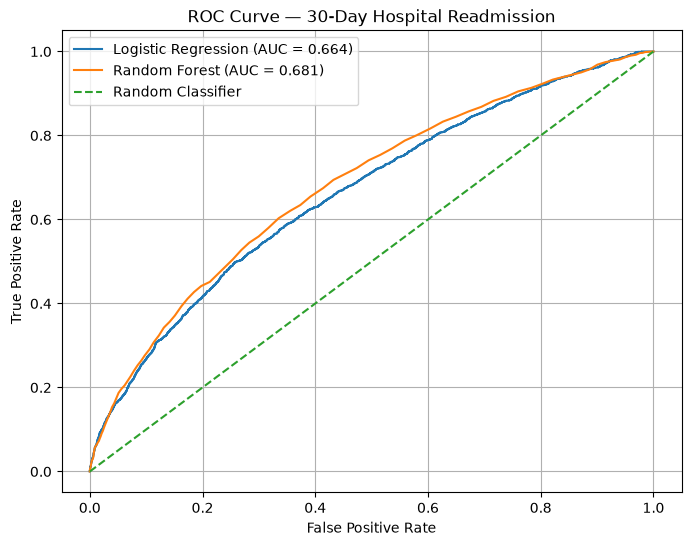

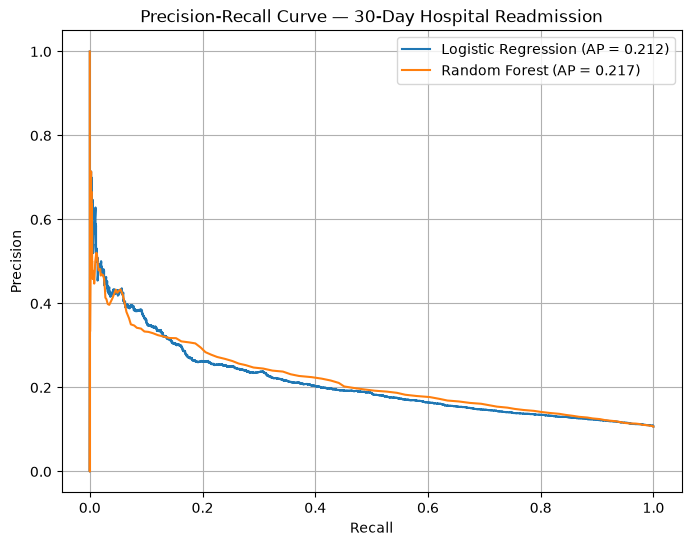

In [20]:
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve
)
import matplotlib.pyplot as plt

# ==============================
# ROC Curve
# ==============================

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_test_proba)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_test_proba)

plt.figure(figsize=(8, 6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC = {lr_metrics['ROC-AUC']:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_metrics['ROC-AUC']:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — 30-Day Hospital Readmission")
plt.legend()
plt.grid(True)
plt.show()


# ==============================
# Precision-Recall Curve
# ==============================

lr_precision, lr_recall, _ = precision_recall_curve(
    y_test,
    lr_test_proba
)

rf_precision, rf_recall, _ = precision_recall_curve(
    y_test,
    rf_test_proba
)

plt.figure(figsize=(8, 6))

plt.plot(
    lr_recall,
    lr_precision,
    label=f"Logistic Regression (AP = {lr_metrics['PR-AUC']:.3f})"
)

plt.plot(
    rf_recall,
    rf_precision,
    label=f"Random Forest (AP = {rf_metrics['PR-AUC']:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — 30-Day Hospital Readmission")
plt.legend()
plt.grid(True)
plt.show()